In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import lusee_faraday as ld

%matplotlib widget

In [2]:
from pathlib import Path
DATA_DIR = Path("/home/christian/Documents/research/lusee/lusee_faraday/data/")

## Beam

In [3]:
def plot(
    maps,
    hemisphere_rot=(0, 90, 0),  # up
    coord=None,
    vmin=None,
    vmax=None,
    unit="",
    cmap=None,
    nest=False,
    xsize=800,
    flip="astro",
    graticule=False,
    norm=None,
    column_titles=("$|E_x^{\\theta}|$", "$|E_x^{\\phi}$|"),  # default: None → uncluttered
    #
    # FIGURE SIZE (AAS one-column default)
    #
    width_in=3.5,
    height_in=None,
    #
    # PHYSICAL LAYOUT (inches)
    #
    # left band for row titles
    left_label_band_in=0.28,
    row_title_rotation=90,
    row_title_inset_in=0.04,
    #
    top_title_band_in=0.2,
    top_margin_in=0.06,
    bottom_margin_in=0.60,
    #
    w_gap_in=0.05,
    h_gap_in=0.05,
    #
    # horizontal bottom colorbar settings
    bottom_cbar_gap_in=0.05,
    bottom_cbar_height_in=0.16,
    bottom_cbar_margin_in=0.04,
    #
    fontsize_labels=10,
):
    """
    Clean, compact AAS 1-column 3×2 orthographic Healpix figure.
    Layout based on physical inches (journal-accurate).
    Horizontal bottom shared colorbar.
    Row/column labels not bold.
    """
    rows, cols = 1, 2
    
    # --- Compute available cell width from width budget
    avail_w_in = (width_in
                  - left_label_band_in
                  - (cols - 1) * w_gap_in)
    cell_w_in = avail_w_in / cols
    if cell_w_in <= 0:
        raise ValueError("width_in too small for left band/gaps.")

    # If height is not given → pick the one that allows square cells w/ margins
    vertical_extras = (top_margin_in + top_title_band_in +
                       bottom_margin_in + bottom_cbar_gap_in +
                       bottom_cbar_height_in + bottom_cbar_margin_in)
    if height_in is None:
        height_in = vertical_extras + rows * cell_w_in + (rows - 1) * h_gap_in

    # Check available vertical room for the panels
    avail_h_in = (height_in - vertical_extras - (rows - 1) * h_gap_in)
    cell_h_in = avail_h_in / rows
    if cell_h_in <= 0:
        raise ValueError("height_in too small for top/bottom bands.")

    # Square cells
    cell_in = min(cell_w_in, cell_h_in)

    grid_w_in = cols * cell_in + (cols - 1) * w_gap_in
    grid_h_in = rows * cell_in + (rows - 1) * h_gap_in

    fig = plt.figure(figsize=(width_in, height_in))
    fx = lambda x: x / width_in
    fy = lambda y: y / height_in

    grid_left = fx(left_label_band_in)
    grid_right = 1.0
    grid_bottom = fy(bottom_margin_in + bottom_cbar_gap_in +
                     bottom_cbar_height_in + bottom_cbar_margin_in)
    grid_top = 1.0 - fy(top_margin_in + top_title_band_in)

    band_w = grid_right - grid_left
    band_h = grid_top - grid_bottom

    slack_w = band_w - fx(grid_w_in)
    slack_h = band_h - fy(grid_h_in)
    x0 = grid_left + max(slack_w, 0)/2
    y0 = grid_bottom + max(slack_h, 0)/2

    cell_w = fx(cell_in)
    cell_h = fy(cell_in)
    w_gap = fx(w_gap_in)
    h_gap = fy(h_gap_in)

    # Axes grid coords
    x_positions = [x0, x0 + cell_w + w_gap]
    y_positions = [y0 + (rows - 1 - r)*(cell_h + h_gap) for r in range(rows)]

    axes_grid = [[None]*cols for _ in range(rows)]
    hp_axes = []
    img_handles = []

    if vmin is None:
        vmin = maps.min()
    if vmax is None:
        vmax = maps.max()

    # --- Draw Orthographic maps
    def _draw(ax_rect, mapping, rot):
        ax = fig.add_axes(ax_rect)
        plt.sca(ax)
        m = hp.orthview(
            mapping, coord=coord, rot=rot,
            xsize=xsize, half_sky=True, nest=nest,
            min=vmin, max=vmax, flip=flip, norm=norm,
            cmap=cmap, notext=True,
            cbar=False, hold=True,
            title="", return_projected_map=True,
        )
        # ax.contour(m, levels=[-10, -3], linewidths=0.8, origin="lower", colors="white")
        if graticule:
            hp.graticule(dpar=30, dmer=30)
        return plt.gca()

    for j in range(cols):
        rect = [x_positions[j], y_positions[0], cell_w, cell_h]
        hax = _draw(rect, maps[j], hemisphere_rot)
        axes_grid[0][j] = hax
        hp_axes.append(hax)
        img_handles.append(hax.get_images()[0])

    # --- Column titles (optional)
    if column_titles is not None:
        col_centers = [x_positions[j] + 0.5*cell_w for j in range(cols)]
        y_title = grid_top + fy(top_title_band_in*0.5)
        for j, title in enumerate(column_titles):
            fig.text(col_centers[j], y_title, title,
                     ha="center", va="center",
                     fontsize=fontsize_labels)

    # --- Row titles (left)
    x_text = fx(left_label_band_in - row_title_inset_in)

    # --- Shared horizontal bottom colorbar
    ref_im = img_handles[0]
    sm = mpl.cm.ScalarMappable(norm=ref_im.norm, cmap=ref_im.cmap)
    sm.set_array([])

    tot_width = x_positions[1] + cell_w - x_positions[0]
    width_frac = 0.9
    cbar_w = tot_width * width_frac
    cbar_x = x_positions[0] + (1 - width_frac) / 2
    #cbar_w = (x_positions[1] + cell_w) - x_positions[0]
    cbar_y = fy(bottom_margin_in + bottom_cbar_margin_in)
    cbar_h = fy(bottom_cbar_height_in)

    cax = fig.add_axes([cbar_x, cbar_y, cbar_w, cbar_h])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")#, ticks=[-20, -15, -10, -5, 0, 5], extend="min")
    cbar.ax.tick_params(labelsize=fontsize_labels)

    if unit:
        cbar.set_label(unit, fontsize=fontsize_labels)

    return fig

In [4]:
beam_file = DATA_DIR / "hfss_lbl_3m_75deg.2port.fits"
FREQ = 30
NSIDE = 128
lusee_beam = ld.Beam.from_file(beam_file, frequency=FREQ, nside=NSIDE)
#lusee_beam.precompute_weights()

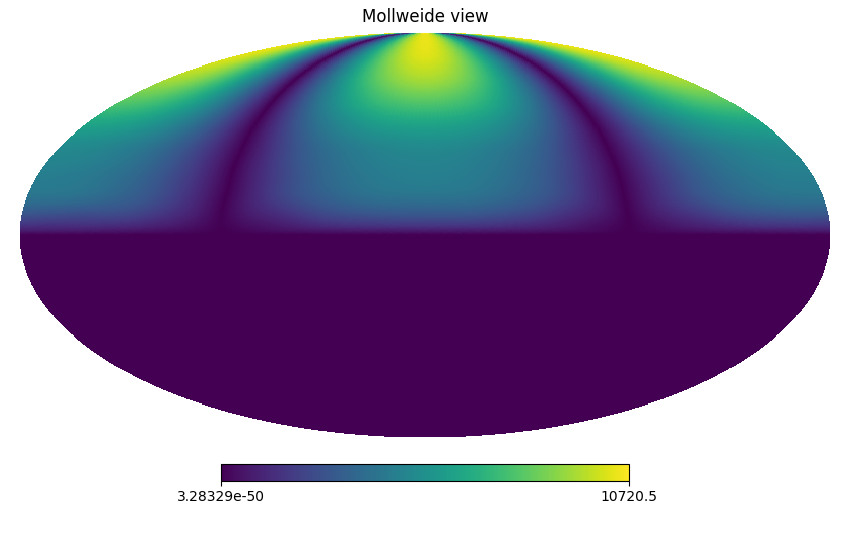

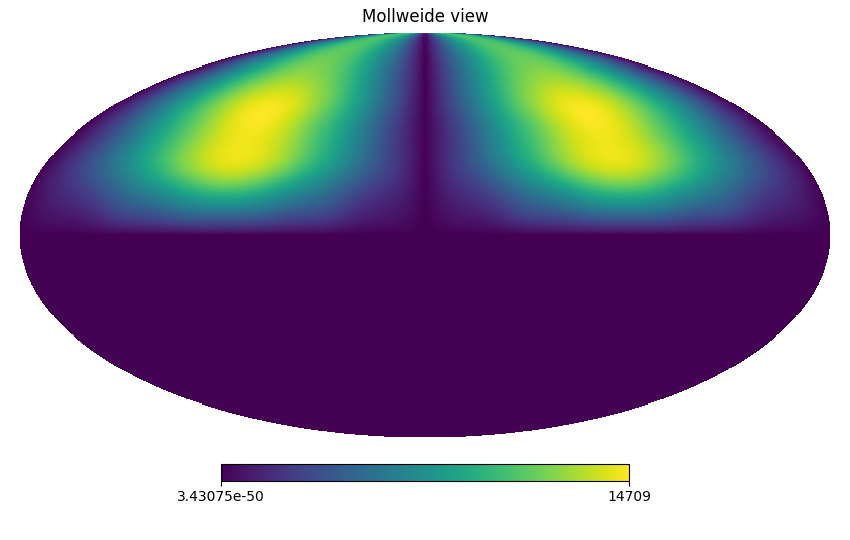

In [5]:
hp.mollview(np.abs(lusee_beam.jones_x[0]), cbar=True)
plt.show()
hp.mollview(np.abs(lusee_beam.jones_x[1]), cbar=True)
plt.show()

In [9]:
fig = plot(np.abs(lusee_beam.jones_x) / np.max(np.abs(lusee_beam.jones_x)), vmin=0, vmax=1, unit="Normalized Linear Gain")
fig.savefig("paper_plots/ln_beam.pdf")

## Spectrometer

In [10]:
spec_path = "../data/spectrometer_bin_response.txt"

with open(spec_path, "r") as f:
    print(f.readline())

# dbin, fbin, pwr, zm0, zm1, zm2, zm3, zm4, zm5, zm6, zm7, zm8, zm9, zm10, zm11, zm12, zm13, zm14, zm15, zm16, zm17, zm18, zm19, zm20, zm21, zm22, zm23, zm24, zm25, zm26, zm27, zm28, zm29, zm30, zm31, zm32, zm33, zm34, zm35, zm36, zm37, zm38, zm39, zm40, zm41, zm42, zm43, zm44, zm45, zm46, zm47, zm48, zm49, zm50, zm51, zm52, zm53, zm54, zm55, zm56, zm57, zm58, zm59, zm60, zm61, zm62, zm63



In [11]:
spec = np.loadtxt(spec_path, skiprows=1)
print(spec.shape)
dbin = spec[:, 0]
fbin = spec[:, 1] / 1e3 # kHz
pwr = spec[:, 2]
pwr /= pwr.sum()  # normalized power - to use for weighted avg
zoom = spec[:, 3:]
zoom /= zoom.sum(axis=0, keepdims=True)

(10001, 67)


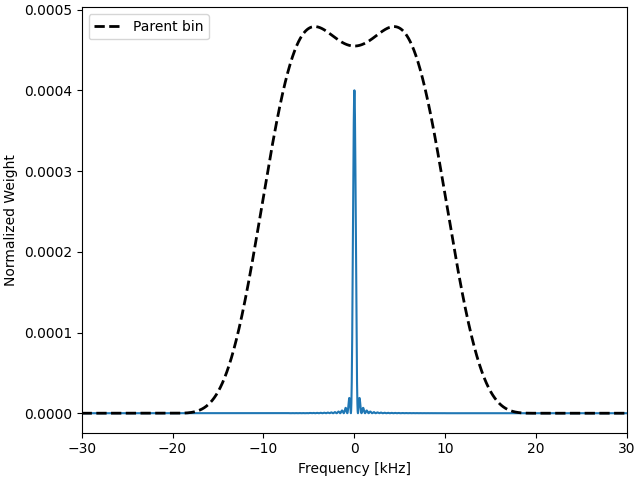

In [39]:
#plt.figure(figsize=(3.5, 2.5))

plt.close()
plt.figure(constrained_layout=True)
#plt.plot(fbin, zoom[:, 0]/64, ls="-", label="Sub-bins")
plt.plot(fbin, pwr, c="k", label="Parent bin", ls="--", lw=2, zorder=1000)  # parent bin
#for i in range(1, 16):
#    plt.plot(fbin, zoom[:, 4*i]/64, ls="-")
plt.plot(fbin, zoom[:, 0]/64)
plt.legend(loc="upper left")
plt.xlim(-30, 30)
plt.xlabel("Frequency [kHz]")
plt.ylabel("Normalized Weight")
#plt.savefig("spec_response.pdf", bbox_inches="tight")
plt.show()

In [23]:
fbin.shape

(10001,)

In [22]:
zoom.shape

(10001, 64)